In [ ]:
(train_images, train_labels), (test_images, test_labels) = some_load_data_function()
# load some data, and preprocess it if necessary

model = tf.keras.Sequential([some_layers])
# create some model

model.compile(optimizer=some_optimizer,
              loss=some_loss_function,
              metrics=['some_metrics'])
# compile the model

model.fit(train_images, train_labels, epochs=10)
# and train it

# you can make predicitions too!
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
# softmax layer to convert logits to probabilities

predictions = probability_model.predict(test_images)
# you can make predicitions from the model too

In [1]:
# imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# load the data
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
print(type(fashion_mnist))
print(type(train_images))
print(type(train_labels))
# module ndarray ndarray

print(train_images.shape, train_labels.shape)
# (60000, 28, 28) (60000,), 60000 images, 28x28 pixels, 1 label

<class 'module'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


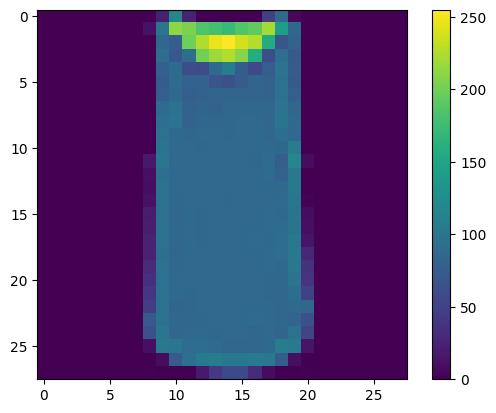

0


In [10]:
def show_image(image):
    """
    Visualize the image
    """
    plt.figure()
    plt.imshow(image)
    plt.colorbar()
    plt.grid(False)
    plt.show()
    
show_image(train_images[2])
print(train_labels[2])

# Data Preprocessing

In [4]:
# scale the images to [0, 1] as opposed to [0, 255]
train_images = train_images / 255.0
test_images = test_images / 255.0

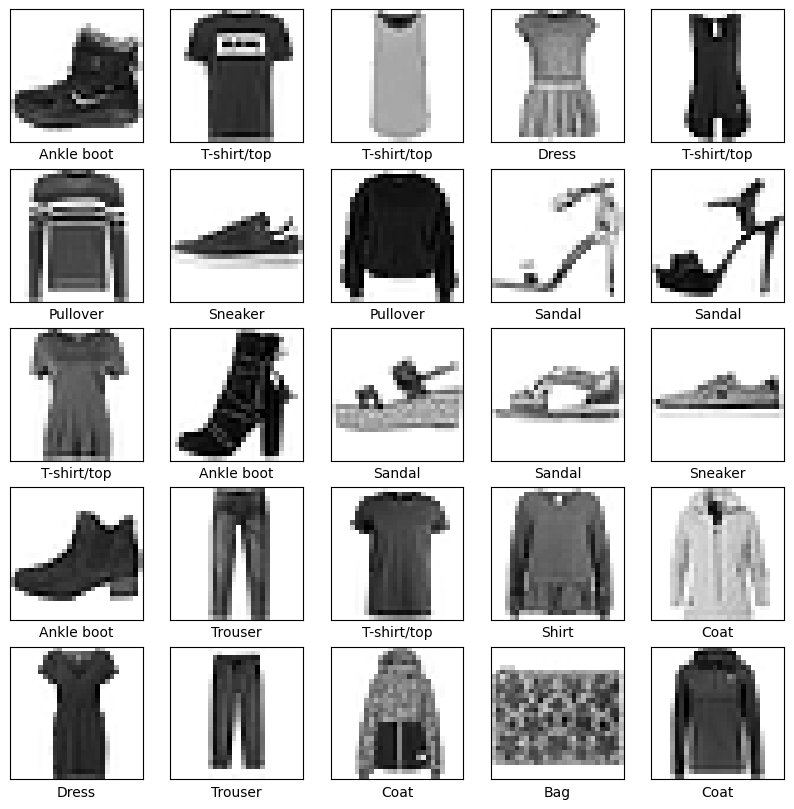

In [14]:
def visualize_first_25_images(class_names, train_images, train_labels):
    """
    Visualize the first 25 images
    """
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(train_images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[train_labels[i]])
    plt.show()

visualize_first_25_images(class_names, train_images, train_labels)

In [15]:
example = train_images[0]
print(example.shape)

(28, 28)


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])
# simple mlp with 1 hidden layer

C:\Users\markt\PycharmProjects\uw-math-notes\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
loaded_model = tf.keras.models.load_model('./models/image_class_mlp.keras')
loaded_model.evaluate(test_images, test_labels, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.8779 - loss: 52.6150


[52.61501693725586, 0.8779000043869019]

In [18]:
print(loaded_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

None


In [19]:
# set up optimizer, loss function, and metrics
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
# train the model
model.fit(train_images, train_labels, epochs=10)

NameError: name 'model' is not defined

In [16]:
model.evaluate(test_images, test_labels, verbose=2)

NameError: name 'model' is not defined

In [8]:
model.save('image_class_mlp.keras')

# Model Predictions

In [21]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(test_images)

In [22]:
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


[7.8674505e-17 1.3217397e-10 0.0000000e+00 2.2146871e-11 0.0000000e+00
 1.7035887e-02 3.1390029e-28 3.6422994e-02 2.4989676e-13 9.4654113e-01]
9
Ankle boot


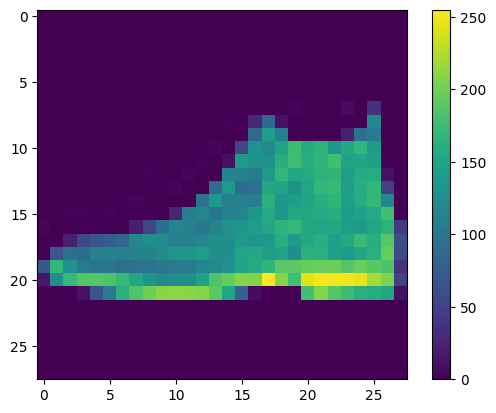

In [23]:
print(predictions[0])
print(np.argmax(predictions[0]))
print(class_names[np.argmax(predictions[0])])
show_image(test_images[0])
# wow it's correct!!!!!

In [24]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [ ]:
def verify_predictions(i: int):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plot_image(i, predictions[i], test_labels, test_images)
    plt.subplot(1,2,2)
    plot_value_array(i, predictions[i],  test_labels)
    plt.show()
    
def visualize_first_25_predictions():
    num_rows = 5
    num_cols = 5
    num_images = num_rows*num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(num_images):
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(i, predictions[i], test_labels, test_images)
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(i, predictions[i], test_labels)
    plt.tight_layout()
    plt.show()
    
visualize_first_25_predictions()

# Using the Model

In [30]:
# like pytorch, predicitons can only be made on a batch of images
img_1 = test_images[0]
img_batch = (np.expand_dims(img_1, 0))
predictions_single = probability_model.predict(img_batch)
print(predictions_single)
print(np.argmax(predictions_single[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[7.8674207e-17 1.3217372e-10 0.0000000e+00 2.2146830e-11 0.0000000e+00
  1.7035887e-02 3.1389788e-28 3.6422994e-02 2.4989630e-13 9.4654113e-01]]
9
